In [89]:
import pandas as pd
import numpy as np
from faker import Faker
import random

In [90]:
fake = Faker()

In [ ]:
occupations = [
  'Software Engineer', 'Teacher', 'Doctor', 'Nurse', 'Accountant', 'Salesperson',
    'Manager', 'Driver', 'Clerk', 'Electrician', 'Mechanic', 'Chef', 'Artist',
    'Scientist', 'Lawyer', 'Police Officer', 'Pharmacist', 'Consultant', 'Analyst', 'Farmer'
]

def generate_row_with_nulls():
  age = random.randint(15,60)
  income = random.randint(15000,100000)
  max_budget = min(income,200000)
  min_budget = 50000

  if max_budget < min_budget:
    budget = max_budget
  else:
    budget = random.randint(min_budget,max_budget)
  ph_no = fake.phone_number()if np.random.rand() > 0.1 else None
  mail_id = fake.email()if np.random.rand() > 0.1 else None
  rented_house = random.choice(['Yes','No'])
  insurance =  random.choice(['Yes','No']) 
  occupation = random.choice(occupations)

  return [age,income,budget,ph_no,mail_id,rented_house,insurance,occupation]

num_rows = 10000

data = [generate_row_with_nulls() for _ in range(num_rows)]

columns = ['age','income','budget','ph_no','mail_id','rented_house','insurance','occupation']

df = pd.DataFrame(data,columns = columns)




In [92]:
df.shape

(10000, 8)

In [93]:
df.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician
2,20,91655,61370,001-810-330-7603x306,None,Yes,Yes,Teacher
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor


In [94]:
df.tail()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
9995,20,26256,26256,001-928-945-3630x24588,rmccullough@example.com,Yes,Yes,Teacher
9996,52,48534,48534,8828218228,kingmichael@example.org,No,No,Doctor
9997,16,37397,37397,491-610-8404x0013,None,No,No,Scientist
9998,60,75385,68424,(896)778-3843x967,jerrymathis@example.org,No,Yes,Mechanic
9999,39,55132,52835,857.651.6918x318,peterclark@example.org,No,Yes,Nurse


In [95]:
df.info

<bound method DataFrame.info of       age  income  budget                   ph_no  \
0      43   40636   40636      425-240-1620x36086   
1      46   67020   53296           (366)201-2293   
2      20   91655   61370    001-810-330-7603x306   
3      53   68257   50895              8806776910   
4      54   68197   67186   +1-423-739-0889x16664   
...   ...     ...     ...                     ...   
9995   20   26256   26256  001-928-945-3630x24588   
9996   52   48534   48534              8828218228   
9997   16   37397   37397       491-610-8404x0013   
9998   60   75385   68424       (896)778-3843x967   
9999   39   55132   52835        857.651.6918x318   

                            mail_id rented_house insurance   occupation  
0             maxwell00@example.net          Yes        No      Teacher  
1           jaimenguyen@example.com          Yes        No  Electrician  
2                              None          Yes       Yes      Teacher  
3               fmiller@example.org

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           10000 non-null  int64 
 1   income        10000 non-null  int64 
 2   budget        10000 non-null  int64 
 3   ph_no         8992 non-null   object
 4   mail_id       9037 non-null   object
 5   rented_house  10000 non-null  object
 6   insurance     10000 non-null  object
 7   occupation    10000 non-null  object
dtypes: int64(3), object(5)
memory usage: 625.1+ KB


In [97]:
df.describe()

,age,income,budget
count,10000.000000,10000.000000,10000.000000
mean,37.627200,57556.748700,50171.811700
std,13.307281,24669.277746,18363.879897
min,15.000000,15008.000000,15008.000000
25%,26.000000,36063.750000,36063.750000
50%,38.000000,57394.500000,51583.000000
75%,49.000000,79162.000000,61972.750000
max,60.000000,99992.000000,98734.000000


In [98]:
df.isna().sum()

age                0
income             0
budget             0
ph_no           1008
mail_id          963
rented_house       0
insurance          0
occupation         0
dtype: int64

In [99]:
df_cleaned = df.dropna(subset=['ph_no']).copy()

In [100]:
df_cleaned.shape

(8992, 8)

In [101]:
df_cleaned.isna().sum()

age               0
income            0
budget            0
ph_no             0
mail_id         860
rented_house      0
insurance         0
occupation        0
dtype: int64

In [102]:
df_cleaned['mail_id'] = df_cleaned['mail_id'].fillna('unknown')

In [103]:
df_cleaned.isna().sum()

age             0
income          0
budget          0
ph_no           0
mail_id         0
rented_house    0
insurance       0
occupation      0
dtype: int64

In [104]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                      860
smithjennifer@example.net      3
johnsonrobert@example.org      3
fsmith@example.com             3
gclark@example.net             3
                            ... 
allenrebecca@example.com       1
rmccullough@example.com        1
kingmichael@example.org        1
jerrymathis@example.org        1
jaimenguyen@example.com        1
Name: count, Length: 8007, dtype: int64

In [105]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician
2,20,91655,61370,001-810-330-7603x306,unknown,Yes,Yes,Teacher
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor


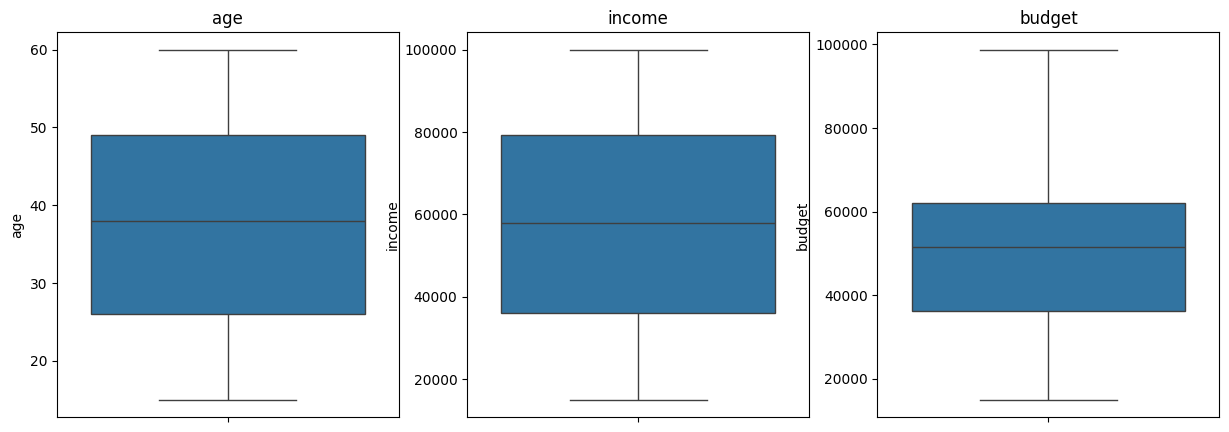

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y = df_cleaned['age'])
plt.title('age')

plt.subplot(1,3,2)
sns.boxplot(y = df_cleaned['income'])
plt.title('income')


plt.subplot(1,3,3)
sns.boxplot(y = df_cleaned['budget'])
plt.title('budget')

plt.show()


In [107]:
df_cleaned.describe(include='all')

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
count,8992.000000,8992.000000,8992.000000,8992,8992,8992,8992,8992
unique,NaN,NaN,NaN,8992,8007,2,2,20
top,NaN,NaN,NaN,6798156716,unknown,No,No,Mechanic
freq,NaN,NaN,NaN,1,860,4504,4503,504
mean,37.667371,57647.807607,50218.444951,NaN,NaN,NaN,NaN,NaN
std,13.308787,24660.905769,18348.121006,NaN,NaN,NaN,NaN,NaN
min,15.000000,15008.000000,15008.000000,NaN,NaN,NaN,NaN,NaN
25%,26.000000,36115.250000,36115.250000,NaN,NaN,NaN,NaN,NaN
50%,38.000000,57839.500000,51635.500000,NaN,NaN,NaN,NaN,NaN
75%,49.000000,79235.750000,61972.750000,NaN,NaN,NaN,NaN,NaN


In [108]:
df_for_clustering = df_cleaned[['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation']]

In [109]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation
0,43,40636,40636,Yes,No,Teacher
1,46,67020,53296,Yes,No,Electrician
2,20,91655,61370,Yes,Yes,Teacher
3,53,68257,50895,Yes,Yes,Scientist
4,54,68197,67186,Yes,Yes,Doctor


In [110]:
df_for_clustering.isna().sum()

age             0
income          0
budget          0
rented_house    0
insurance       0
occupation      0
dtype: int64

In [111]:
df_for_clustering.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8992 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           8992 non-null   int64 
 1   income        8992 non-null   int64 
 2   budget        8992 non-null   int64 
 3   rented_house  8992 non-null   object
 4   insurance     8992 non-null   object
 5   occupation    8992 non-null   object
dtypes: int64(3), object(3)
memory usage: 491.8+ KB


In [112]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans.fit(df_for_clustering[['age', 'income', 'budget']])
df_for_clustering['cluster'] = kmeans.labels_


C:\Users\DELL\AppData\Local\Temp\ipykernel_13112\1344914568.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_clustering['cluster'] = kmeans.labels_


In [113]:
type(df_for_clustering)

pandas.core.frame.DataFrame

In [114]:
df_cleaned_with_clusters = df_cleaned.copy()

In [115]:
df_cleaned_with_clusters["cluster_with_num_cols_only"] = kmeans.labels_

In [116]:
df_cleaned_with_clusters.head()  

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher,1
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician,0
2,20,91655,61370,001-810-330-7603x306,unknown,Yes,Yes,Teacher,2
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist,0
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor,2


In [117]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
0    3122
2    3029
1    2841
Name: count, dtype: int64

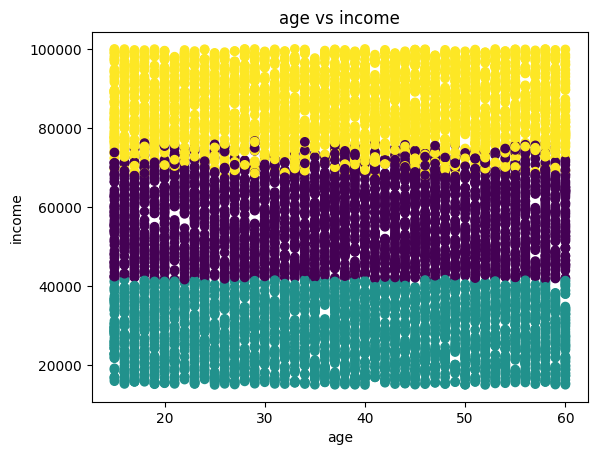

In [118]:
plt.scatter(df_cleaned_with_clusters['age'],df_cleaned_with_clusters['income'],c =df_cleaned_with_clusters['cluster_with_num_cols_only'],cmap = 'viridis')
plt.xlabel('age')
plt.ylabel('income')
plt.title('age vs income')
plt.show()

In [119]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician
2,20,91655,61370,001-810-330-7603x306,unknown,Yes,Yes,Teacher
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor


In [120]:
df_cleaned.shape

(8992, 8)

In [121]:
df_for_clustering.head(2)

,age,income,budget,rented_house,insurance,occupation,cluster
0,43,40636,40636,Yes,No,Teacher,1
1,46,67020,53296,Yes,No,Electrician,0


In [122]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher,1
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician,0


In [123]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                      860
smithjennifer@example.net      3
johnsonrobert@example.org      3
fsmith@example.com             3
gclark@example.net             3
                            ... 
allenrebecca@example.com       1
rmccullough@example.com        1
kingmichael@example.org        1
jerrymathis@example.org        1
jaimenguyen@example.com        1
Name: count, Length: 8007, dtype: int64

In [124]:
df_cleaned_wo_duplicates = df_cleaned.drop_duplicates()

In [125]:
df_cleaned_wo_duplicates.shape

(8992, 8)

In [126]:
df_cleaned_wo_duplicates_ph_mail = df_cleaned.drop_duplicates(subset = ['ph_no','mail_id'])

In [127]:
df_cleaned_wo_duplicates.shape

(8992, 8)

In [128]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                      860
smithjennifer@example.net      3
johnsonrobert@example.org      3
fsmith@example.com             3
gclark@example.net             3
                            ... 
allenrebecca@example.com       1
rmccullough@example.com        1
kingmichael@example.org        1
jerrymathis@example.org        1
jaimenguyen@example.com        1
Name: count, Length: 8007, dtype: int64

In [129]:
df_cleaned_wo_duplicates_mail = df_cleaned.drop_duplicates(subset=['mail_id'])

In [130]:
df_cleaned_wo_duplicates_mail.shape

(8007, 8)

In [131]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster
0,43,40636,40636,Yes,No,Teacher,1
1,46,67020,53296,Yes,No,Electrician,0
2,20,91655,61370,Yes,Yes,Teacher,2
3,53,68257,50895,Yes,Yes,Scientist,0
4,54,68197,67186,Yes,Yes,Doctor,2


In [132]:
df_for_clustering['rented_house'].value_counts()

rented_house
No     4504
Yes    4488
Name: count, dtype: int64

In [133]:
df_for_clustering['insurance'].value_counts()

insurance
No     4503
Yes    4489
Name: count, dtype: int64

In [134]:
df_for_clustering['occupation'].nunique()

20

In [135]:
df_for_clustering['occupation'].value_counts()

occupation
Mechanic             504
Teacher              479
Driver               476
Nurse                470
Pharmacist           466
Electrician          458
Clerk                455
Consultant           454
Chef                 451
Salesperson          447
Software Engineer    446
Manager              444
Lawyer               441
Scientist            438
Analyst              436
Police Officer       433
Farmer               428
Accountant           423
Doctor               422
Artist               421
Name: count, dtype: int64

In [136]:
df_cleaned_with_clusters

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher,1
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician,0
2,20,91655,61370,001-810-330-7603x306,unknown,Yes,Yes,Teacher,2
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist,0
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor,2
...,...,...,...,...,...,...,...,...,...
9995,20,26256,26256,001-928-945-3630x24588,rmccullough@example.com,Yes,Yes,Teacher,1
9996,52,48534,48534,8828218228,kingmichael@example.org,No,No,Doctor,0
9997,16,37397,37397,491-610-8404x0013,unknown,No,No,Scientist,1
9998,60,75385,68424,(896)778-3843x967,jerrymathis@example.org,No,Yes,Mechanic,2


In [137]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_for_clustering['rented_house_label'] = label_encoder.fit_transform(df_for_clustering['rented_house'])

In [138]:
df_for_clustering

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label
0,43,40636,40636,Yes,No,Teacher,1,1
1,46,67020,53296,Yes,No,Electrician,0,1
2,20,91655,61370,Yes,Yes,Teacher,2,1
3,53,68257,50895,Yes,Yes,Scientist,0,1
4,54,68197,67186,Yes,Yes,Doctor,2,1
...,...,...,...,...,...,...,...,...
9995,20,26256,26256,Yes,Yes,Teacher,1,1
9996,52,48534,48534,No,No,Doctor,0,0
9997,16,37397,37397,No,No,Scientist,1,0
9998,60,75385,68424,No,Yes,Mechanic,2,0


In [139]:
df_for_clustering['insurance_label'] = label_encoder.fit_transform(df_for_clustering['insurance'])

In [140]:
df_for_clustering

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label
0,43,40636,40636,Yes,No,Teacher,1,1,0
1,46,67020,53296,Yes,No,Electrician,0,1,0
2,20,91655,61370,Yes,Yes,Teacher,2,1,1
3,53,68257,50895,Yes,Yes,Scientist,0,1,1
4,54,68197,67186,Yes,Yes,Doctor,2,1,1
...,...,...,...,...,...,...,...,...,...
9995,20,26256,26256,Yes,Yes,Teacher,1,1,1
9996,52,48534,48534,No,No,Doctor,0,0,0
9997,16,37397,37397,No,No,Scientist,1,0,0
9998,60,75385,68424,No,Yes,Mechanic,2,0,1


In [141]:
df_for_clustering['occupation_label'] = label_encoder.fit_transform(df_for_clustering['occupation'])

In [142]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label,occupation_label
0,43,40636,40636,Yes,No,Teacher,1,1,0,19
1,46,67020,53296,Yes,No,Electrician,0,1,0,8
2,20,91655,61370,Yes,Yes,Teacher,2,1,1,19
3,53,68257,50895,Yes,Yes,Scientist,0,1,1,17
4,54,68197,67186,Yes,Yes,Doctor,2,1,1,6


In [143]:
df_for_clustering.columns

Index(['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation',
       'cluster', 'rented_house_label', 'insurance_label', 'occupation_label'],
      dtype='object')

In [144]:
df_with_label_encoded = df_for_clustering[['age','income','budget','rented_house_label','insurance_label','occupation_label']]

In [145]:
df_with_label_encoded.head()

,age,income,budget,rented_house_label,insurance_label,occupation_label
0,43,40636,40636,1,0,19
1,46,67020,53296,1,0,8
2,20,91655,61370,1,1,19
3,53,68257,50895,1,1,17
4,54,68197,67186,1,1,6


In [146]:
df_with_label_encoded.isna().sum()

age                   0
income                0
budget                0
rented_house_label    0
insurance_label       0
occupation_label      0
dtype: int64

In [147]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)

kmeans.fit(df_with_label_encoded)

df_cleaned_with_clusters['cluster_with_cat_cols_only'] = kmeans.labels_


In [148]:
df_cleaned_with_clusters

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only,cluster_with_cat_cols_only
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher,1,1
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician,0,0
2,20,91655,61370,001-810-330-7603x306,unknown,Yes,Yes,Teacher,2,2
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist,0,0
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor,2,2
...,...,...,...,...,...,...,...,...,...,...
9995,20,26256,26256,001-928-945-3630x24588,rmccullough@example.com,Yes,Yes,Teacher,1,1
9996,52,48534,48534,8828218228,kingmichael@example.org,No,No,Doctor,0,0
9997,16,37397,37397,491-610-8404x0013,unknown,No,No,Scientist,1,1
9998,60,75385,68424,(896)778-3843x967,jerrymathis@example.org,No,Yes,Mechanic,2,2


In [149]:
df_cleaned_with_clusters.head(2)

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation,cluster_with_num_cols_only,cluster_with_cat_cols_only
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher,1,1
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician,0,0


In [150]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
0    3122
2    3029
1    2841
Name: count, dtype: int64

In [151]:
df_cleaned_with_clusters['cluster_with_cat_cols_only'].value_counts()

cluster_with_cat_cols_only
0    3120
2    3034
1    2838
Name: count, dtype: int64

In [152]:
df_with_label_encoded.head()

,age,income,budget,rented_house_label,insurance_label,occupation_label
0,43,40636,40636,1,0,19
1,46,67020,53296,1,0,8
2,20,91655,61370,1,1,19
3,53,68257,50895,1,1,17
4,54,68197,67186,1,1,6


In [153]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

x = df_with_label_encoded

wcss = []
silhouette_scores = []

K = range(2,11)
print("printing k values after range function")
print(K)

for k in K:
  print(k)
  kmeans = KMeans(n_clusters = k, random_state = 42)
  labels = kmeans.fit_predict(x)

  wcss.append(kmeans.inertia_)
  print("wcss score is ")
  print(wcss)
  silhouette_scores.append(silhouette_score(x,labels))
  print("silhouette scores is")
  print(silhouette_scores)


printing k values after range function
range(2, 11)
2
wcss score is 
[2466922366814.193]
silhouette scores is
[0.5862849700633933]
3
wcss score is 
[2466922366814.193, 1267294927256.4897]
silhouette scores is
[0.5862849700633933, 0.5309177250906765]
4
wcss score is 
[2466922366814.193, 1267294927256.4897, 855036661546.8933]
silhouette scores is
[0.5862849700633933, 0.5309177250906765, 0.4899450555499351]
5
wcss score is 
[2466922366814.193, 1267294927256.4897, 855036661546.8933, 617284261942.8649]
silhouette scores is
[0.5862849700633933, 0.5309177250906765, 0.4899450555499351, 0.47566411199565095]
6
wcss score is 
[2466922366814.193, 1267294927256.4897, 855036661546.8933, 617284261942.8649, 463560973325.9573]
silhouette scores is
[0.5862849700633933, 0.5309177250906765, 0.4899450555499351, 0.47566411199565095, 0.47837487638040715]
7
wcss score is 
[2466922366814.193, 1267294927256.4897, 855036661546.8933, 617284261942.8649, 463560973325.9573, 376618924717.45856]
silhouette scores is
[

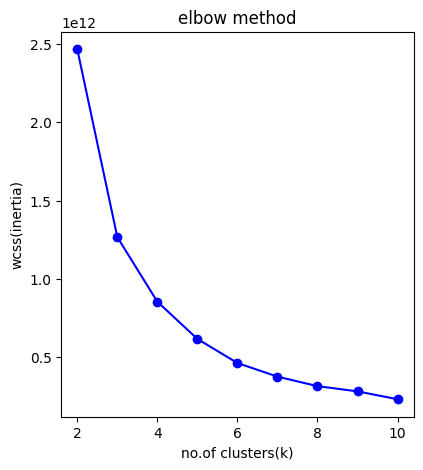

In [154]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("elbow method")
plt.plot(K, wcss, 'bo-')
plt.xlabel('no.of clusters(k)')
plt.ylabel('wcss(inertia)')
plt.show()


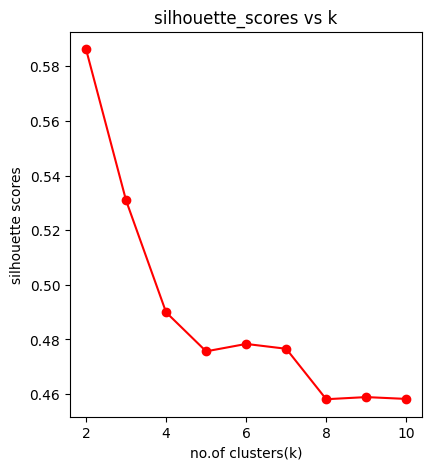

In [155]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,2)
plt.title("silhouette_scores vs k")
plt.plot(K,silhouette_scores,'ro-')

plt.xlabel('no.of clusters(k)')
plt.ylabel('silhouette scores')
plt.show()

In [156]:
df_for_clustering_with_onehot = pd.get_dummies(df_for_clustering, dtype=float)

In [157]:
df_for_clustering_with_onehot.isna().sum()

age                             0
income                          0
budget                          0
cluster                         0
rented_house_label              0
insurance_label                 0
occupation_label                0
rented_house_No                 0
rented_house_Yes                0
insurance_No                    0
insurance_Yes                   0
occupation_Accountant           0
occupation_Analyst              0
occupation_Artist               0
occupation_Chef                 0
occupation_Clerk                0
occupation_Consultant           0
occupation_Doctor               0
occupation_Driver               0
occupation_Electrician          0
occupation_Farmer               0
occupation_Lawyer               0
occupation_Manager              0
occupation_Mechanic             0
occupation_Nurse                0
occupation_Pharmacist           0
occupation_Police Officer       0
occupation_Salesperson          0
occupation_Scientist            0
occupation_Sof

In [158]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42) 
kmeans.fit(df_for_clustering_with_onehot)

df_cleaned_with_clusters['cluster_with_onehot'] = kmeans.labels_

In [159]:
df_cleaned_with_clusters['cluster_with_onehot'].value_counts()

cluster_with_onehot
0    3122
2    3048
1    2822
Name: count, dtype: int64

In [160]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

df_rented_house_encoded = encoder.fit_transform(df_for_clustering[['rented_house']])
df_rented_house_encoded = pd.DataFrame(df_rented_house_encoded, columns=encoder.get_feature_names_out(['rented_house']))
df_for_clustering = pd.concat([df_for_clustering, df_rented_house_encoded], axis=1)

In [161]:
df_rented_house_encoded

,rented_house_No,rented_house_Yes
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
8987,0.0,1.0
8988,1.0,0.0
8989,1.0,0.0
8990,1.0,0.0


In [162]:
df_for_clustering['insurance'].value_counts()

insurance
No     4503
Yes    4489
Name: count, dtype: int64

In [163]:
encoder = OneHotEncoder(sparse_output=False)


df_insurance_encoded = encoder.fit_transform(df_for_clustering[['insurance']])
df_insurance_encoded = pd.DataFrame(df_insurance_encoded, columns=encoder.get_feature_names_out(['insurance']))
df_for_clustering = pd.concat([df_for_clustering, df_insurance_encoded], axis=1)

In [164]:
df_for_clustering = df_for_clustering.drop('insurance_nan', axis=1)

In [165]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label,occupation_label,rented_house_No,rented_house_Yes,insurance_No,insurance_Yes
0,43.0,40636.0,40636.0,Yes,No,Teacher,1.0,1.0,0.0,19.0,0.0,1.0,1.0,0.0
1,46.0,67020.0,53296.0,Yes,No,Electrician,0.0,1.0,0.0,8.0,0.0,1.0,1.0,0.0
2,20.0,91655.0,61370.0,Yes,Yes,Teacher,2.0,1.0,1.0,19.0,0.0,1.0,0.0,1.0
3,53.0,68257.0,50895.0,Yes,Yes,Scientist,0.0,1.0,1.0,17.0,0.0,1.0,0.0,1.0
4,54.0,68197.0,67186.0,Yes,Yes,Doctor,2.0,1.0,1.0,6.0,0.0,1.0,0.0,1.0


In [166]:
encoder = OneHotEncoder(sparse_output=False)

df_occupation_encoded = encoder.fit_transform(df_for_clustering[['occupation']])
df_occupation_encoded = pd.DataFrame(df_occupation_encoded, columns=encoder.get_feature_names_out(['occupation']))
df_for_clustering = pd.concat([df_for_clustering, df_occupation_encoded], axis=1)

In [167]:
df_for_clustering.shape

(10000, 35)

In [168]:
import pandas as pd
pd.set_option('display.max_columns', None)
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label,occupation_label,rented_house_No,rented_house_Yes,insurance_No,insurance_Yes,occupation_Accountant,occupation_Analyst,occupation_Artist,occupation_Chef,occupation_Clerk,occupation_Consultant,occupation_Doctor,occupation_Driver,occupation_Electrician,occupation_Farmer,occupation_Lawyer,occupation_Manager,occupation_Mechanic,occupation_Nurse,occupation_Pharmacist,occupation_Police Officer,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher,occupation_nan
0,43.0,40636.0,40636.0,Yes,No,Teacher,1.0,1.0,0.0,19.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,46.0,67020.0,53296.0,Yes,No,Electrician,0.0,1.0,0.0,8.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20.0,91655.0,61370.0,Yes,Yes,Teacher,2.0,1.0,1.0,19.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,53.0,68257.0,50895.0,Yes,Yes,Scientist,0.0,1.0,1.0,17.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,54.0,68197.0,67186.0,Yes,Yes,Doctor,2.0,1.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [169]:
df.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,43,40636,40636,425-240-1620x36086,maxwell00@example.net,Yes,No,Teacher
1,46,67020,53296,(366)201-2293,jaimenguyen@example.com,Yes,No,Electrician
2,20,91655,61370,001-810-330-7603x306,None,Yes,Yes,Teacher
3,53,68257,50895,8806776910,fmiller@example.org,Yes,Yes,Scientist
4,54,68197,67186,+1-423-739-0889x16664,jenniferrasmussen@example.com,Yes,Yes,Doctor


In [170]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation,cluster,rented_house_label,insurance_label,occupation_label,rented_house_No,rented_house_Yes,insurance_No,insurance_Yes,occupation_Accountant,occupation_Analyst,occupation_Artist,occupation_Chef,occupation_Clerk,occupation_Consultant,occupation_Doctor,occupation_Driver,occupation_Electrician,occupation_Farmer,occupation_Lawyer,occupation_Manager,occupation_Mechanic,occupation_Nurse,occupation_Pharmacist,occupation_Police Officer,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher,occupation_nan
0,43.0,40636.0,40636.0,Yes,No,Teacher,1.0,1.0,0.0,19.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,46.0,67020.0,53296.0,Yes,No,Electrician,0.0,1.0,0.0,8.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20.0,91655.0,61370.0,Yes,Yes,Teacher,2.0,1.0,1.0,19.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,53.0,68257.0,50895.0,Yes,Yes,Scientist,0.0,1.0,1.0,17.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,54.0,68197.0,67186.0,Yes,Yes,Doctor,2.0,1.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [175]:
df_with_label_encoding_data = df_for_clustering[['age', 'income', 'budget', 'rented_house_label', 'insurance_label', 'occupation_label']]

In [176]:
df_with_label_encoding_data.head(2)

,age,income,budget,rented_house_label,insurance_label,occupation_label
0,43.0,40636.0,40636.0,1.0,0.0,19.0
1,46.0,67020.0,53296.0,1.0,0.0,8.0


In [178]:
df_with_label_encoding_data.isna().sum()

age                   1008
income                1008
budget                1008
rented_house_label    1008
insurance_label       1008
occupation_label      1008
dtype: int64

In [179]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_with_label_encoding_data)


df_with_label_encoding_data['cluster'] = kmeans.labels_

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values